<a href="https://colab.research.google.com/github/FernandaVil/unet-sst-inpainting/blob/main/01_extraccion_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install zarr s3fs xarray matplotlib

In [ ]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [ ]:


# conectarnos al catálogo en amazon web services
url = 'https://mur-sst.s3.us-west-2.amazonaws.com/zarr-v1'
ds = xr.open_zarr(url, consolidated=True)

print("variables disponibles y sus metadatos oficiales:\n")

# iterar sobre cada variable para imprimir su documentación interna
for var in ds.data_vars:
    print(f"--- variable: {var} ---")

    # extraer los atributos descriptivos (si no existen, devuelve un texto por defecto)
    long_name = ds[var].attrs.get('long_name', 'no especificado')
    units = ds[var].attrs.get('units', 'adimensional / no especificado')
    comment = ds[var].attrs.get('comment', 'sin notas adicionales')

    print(f" significado : {long_name}")
    print(f" unidades    : {units}")
    print(f" notas       : {comment}\n")

variables disponibles y sus metadatos oficiales:

--- variable: analysed_sst ---
 significado : analysed sea surface temperature
 unidades    : kelvin
 notas       : "Final" version using Multi-Resolution Variational Analysis (MRVA) method for interpolation

--- variable: analysis_error ---
 significado : estimated error standard deviation of analysed_sst
 unidades    : kelvin
 notas       : none

--- variable: mask ---
 significado : sea/land field composite mask
 unidades    : adimensional / no especificado
 notas       : mask can be used to further filter the data.

--- variable: sea_ice_fraction ---
 significado : sea ice area fraction
 unidades    : fraction (between 0 and 1)
 notas       : ice data interpolated by a nearest neighbor approach.



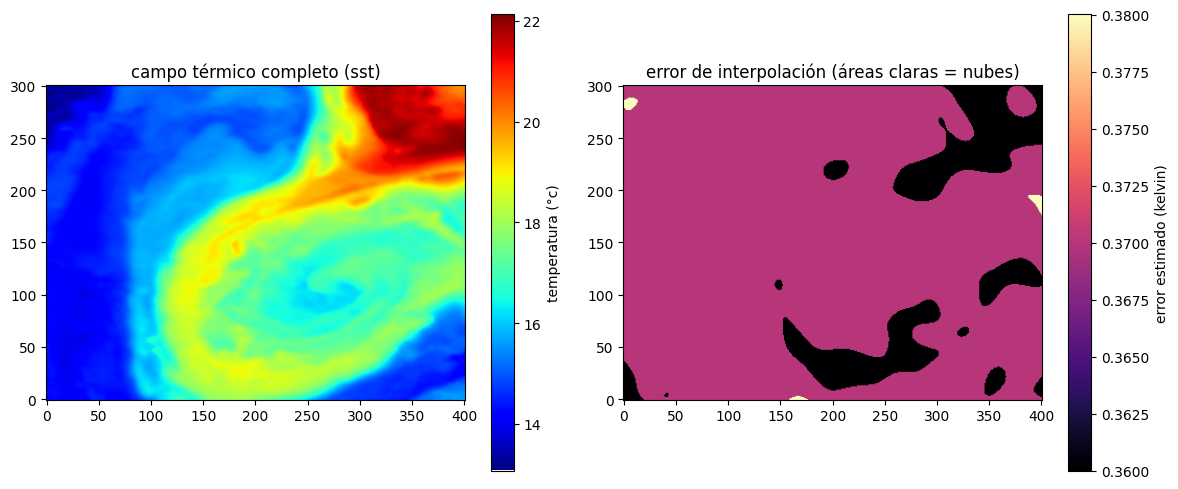

In [ ]:


# recortar región de interés
lat_min, lat_max = -44.0, -41.0
lon_min, lon_max = -57.0, -53.0

corte = ds.sel(
    time='2020-03-15',
    method='nearest'
).sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# 3. extraer ambas matrices a la memoria ram
matriz_sst = corte['analysed_sst'].squeeze().values - 273.15
matriz_error = corte['analysis_error'].squeeze().values

# 4. graficar para comparar la temperatura vs. el error
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# gráfico izquierdo: el campo térmico de nivel 4
im1 = ax1.imshow(matriz_sst, origin='lower', cmap='jet')
ax1.set_title('campo térmico completo (sst)')
fig.colorbar(im1, ax=ax1, label='temperatura (°c)')

# gráfico derecho: el mapa del error (la huella de las nubes)
im2 = ax2.imshow(matriz_error, origin='lower', cmap='magma')
ax2.set_title('error de interpolación (áreas claras = nubes)')
fig.colorbar(im2, ax=ax2, label='error estimado (kelvin)')

plt.tight_layout()
plt.show()

In [ ]:
# NO EJECUTAR OTRA VEZ , YA ESTAN DESCARGADOS

# montar el almacenamiento virtual
drive.mount('/content/drive')

# crear el directorio definitivo
ruta_salida = '/content/drive/MyDrive/dataset-sst-confluencia'
os.makedirs(ruta_salida, exist_ok=True)

# conectar al catálogo público
url = 'https://mur-sst.s3.us-west-2.amazonaws.com/zarr-v1'
ds = xr.open_zarr(url, consolidated=True)

lat_min, lat_max = -44.0, -41.0
lon_min, lon_max = -57.0, -53.0

# realizar el recorte espaciotemporal masivo (3 años completos)
cubo_recortado = ds.sel(
    time=slice('2017-01-01', '2019-12-31'),
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

print(f"iniciando la descarga de {len(cubo_recortado.time)} matrices diarias...")

# iterar, descargar y comprimir localmente
for fecha in cubo_recortado.time.values:
    fecha_str = str(fecha)[:10]

    dia_actual = cubo_recortado.sel(time=fecha_str, method='nearest')

    # bajar matrices a ram (temperatura en celsius para estabilidad nuemrica de pytorch)
    matriz_sst = dia_actual['analysed_sst'].squeeze().values - 273.15
    matriz_error = dia_actual['analysis_error'].squeeze().values # 1K equivale a 1°C de error

    # empaquetar en un archivo comprimido .npz
    nombre_archivo = f"{ruta_salida}/tensor_{fecha_str}.npz"
    np.savez_compressed(nombre_archivo, sst=matriz_sst, error=matriz_error)

    if fecha_str.endswith('01') or fecha_str.endswith('15'):
        print(f"guardado exitosamente: {fecha_str}")

print("proceso de adquisición de datos finalizado.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
iniciando la descarga de 1095 matrices diarias...
guardado exitosamente: 2017-01-01
guardado exitosamente: 2017-01-15
guardado exitosamente: 2017-02-01
guardado exitosamente: 2017-02-15
guardado exitosamente: 2017-03-01
guardado exitosamente: 2017-03-15
guardado exitosamente: 2017-04-01
guardado exitosamente: 2017-04-15
guardado exitosamente: 2017-05-01
guardado exitosamente: 2017-05-15
guardado exitosamente: 2017-06-01
guardado exitosamente: 2017-06-15
guardado exitosamente: 2017-07-01
guardado exitosamente: 2017-07-15
guardado exitosamente: 2017-08-01
guardado exitosamente: 2017-08-15
guardado exitosamente: 2017-09-01
guardado exitosamente: 2017-09-15
guardado exitosamente: 2017-10-01
guardado exitosamente: 2017-10-15
guardado exitosamente: 2017-11-01
guardado exitosamente: 2017-11-15
guardado exitosamente: 2017-12-01
guardado exitosamente: 2017-12-15
guard

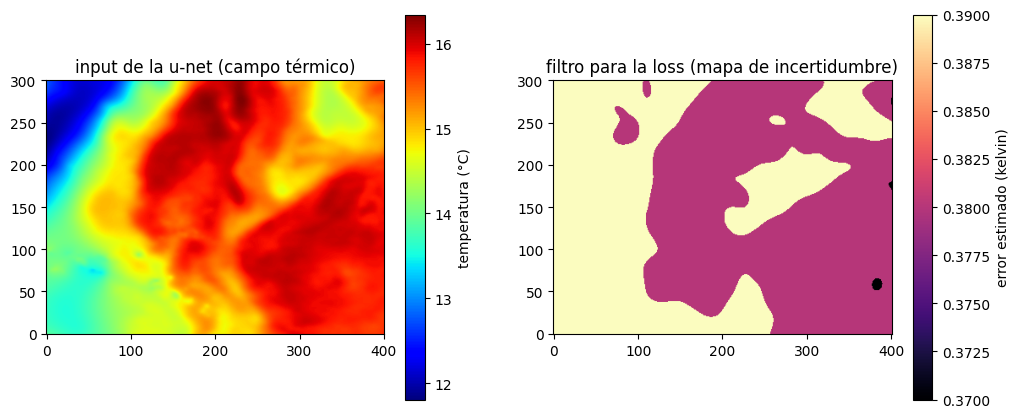

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# cargar un archivo específico guardado en tu google drive
# usamos 2017 porque es el rango que acabas de descargar
ruta_archivo = '/content/drive/MyDrive/dataset_sst_confluencia/tensor_2017-01-15.npz'
archivo = np.load(ruta_archivo)

# extraer las dos matrices numéricas
matriz_sst = archivo['sst']
matriz_error = archivo['error']

# graficar traduciendo los números a colores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(matriz_sst, origin='lower', cmap='jet')
ax1.set_title('input de la u-net (campo térmico)')
fig.colorbar(im1, ax=ax1, label='temperatura (°C)')

im2 = ax2.imshow(matriz_error, origin='lower', cmap='magma')
ax2.set_title('filtro para la loss (mapa de incertidumbre)')
fig.colorbar(im2, ax=ax2, label='error estimado (kelvin)')

plt.show()

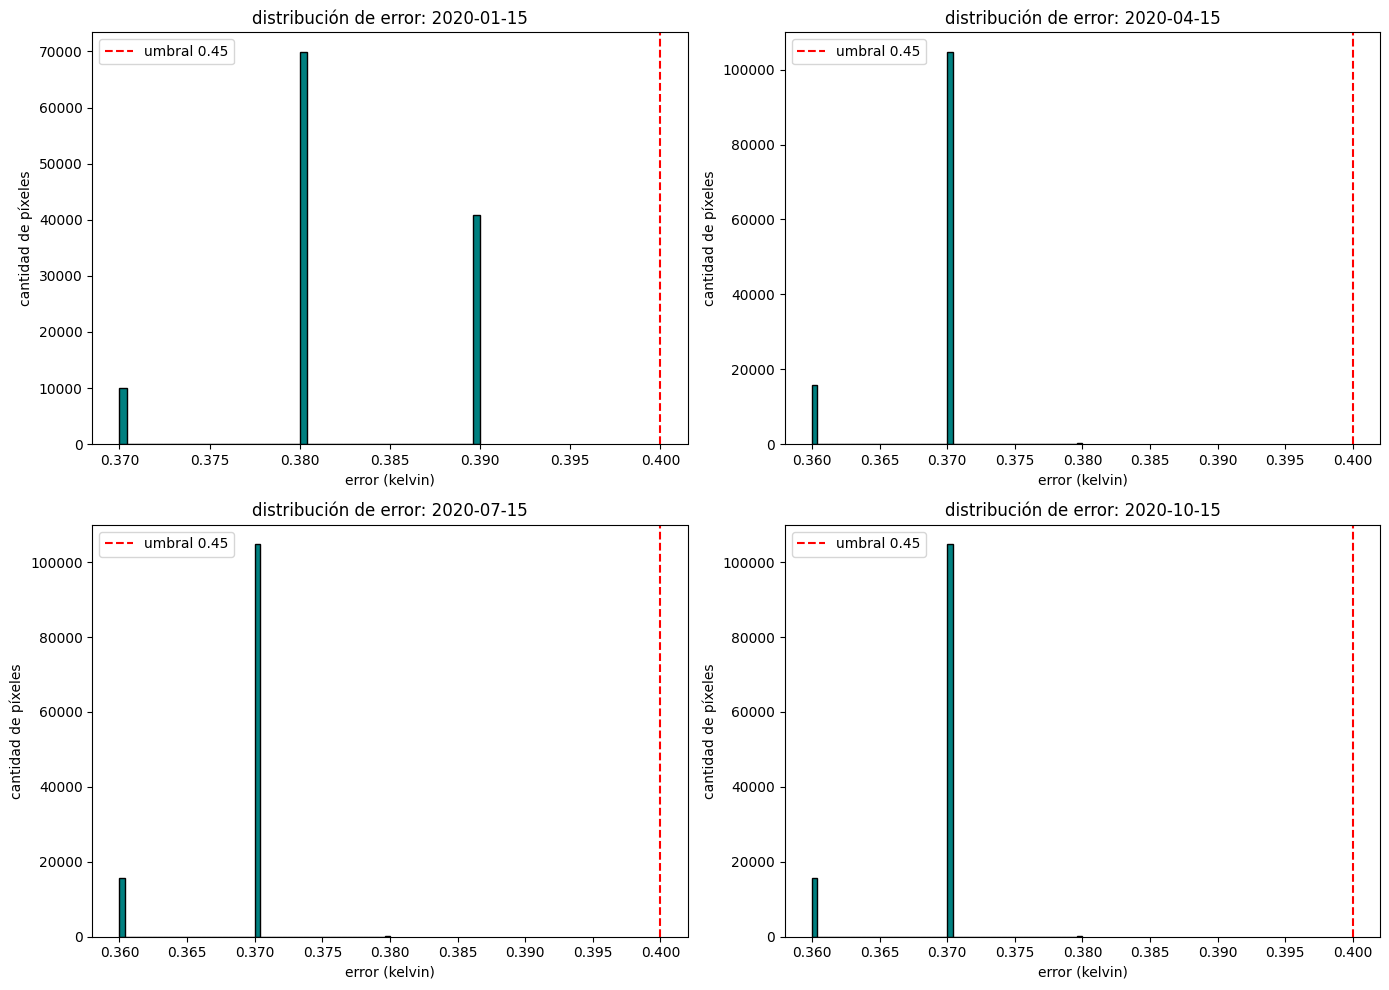

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# 1. conexión al catálogo
url = 'https://mur-sst.s3.us-west-2.amazonaws.com/zarr-v1'
ds = xr.open_zarr(url, consolidated=True)

lat_min, lat_max = -44.0, -41.0
lon_min, lon_max = -57.0, -53.0

# 2. definir cuatro días representativos del ciclo anual
fechas_prueba = ['2020-01-15', '2020-04-15', '2020-07-15', '2020-10-15']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# 3. iterar sobre las fechas y graficar sus distribuciones
for i, fecha in enumerate(fechas_prueba):
    corte = ds.sel(time=fecha, method='nearest').sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max)
    )

    error = corte['analysis_error'].squeeze().values

    # graficar el histograma de cada fecha
    axs[i].hist(error.flatten(), bins=50, color='teal', edgecolor='black')
    axs[i].set_title(f'distribución de error: {fecha}')
    axs[i].set_xlabel('error (kelvin)')
    axs[i].set_ylabel('cantidad de píxeles')

    # línea de referencia en 0.45 para evaluar consistencia
    axs[i].axvline(x=0.40, color='red', linestyle='--', label='umbral 0.40')
    axs[i].legend()

plt.tight_layout()
plt.show()